<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
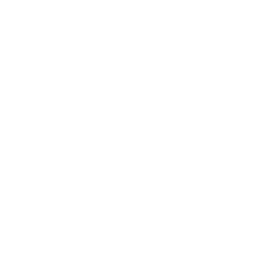
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ingesta de Resultados de Laboratorio Central Clínico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacéutica / Bioestadística &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Importa un archivo CSV de un laboratorio central que contiene paneles de química clínica y hematología para un ensayo oncológico de Fase II. Se usa GUESSINGROWS=MAX para garantizar que los tipos de variable se infieran correctamente en todo el conjunto de datos, evitando que campos numéricos dispersos se clasifiquen erróneamente como carácter. El conjunto de datos importado se alimenta a `PROC MEANS` con ODS OUTPUT para generar estadísticas resumen de rangos de referencia estratificadas por analito y visita, respaldando la revisión de valores normales de laboratorio por parte del monitor médico.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| central_lab_results.csv | Exportación CSV del laboratorio central con paneles de química y hematología | ~5,000 |
| WORK.LAB_IMPORT | Conjunto de datos SAS importado mediante PROC IMPORT | ~5,000 |

---

In [1]:
/* --------------------------------------------------------
   Genera un archivo CSV sintético de laboratorio central
   Columnas: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
             LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
             LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
DATOS work.lab_csv_source;
    LLAMAR streaminit(42);
    LONGITUD usubjid $16 visit $20 lbtestcd $8 lbtest $35
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    ARREGLO test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    ARREGLO test_cats[8] $15 _temporary_
        ('CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY'
         'CHEMISTRY' 'HEMATOLOGY' 'HEMATOLOGY' 'HEMATOLOGY');
    ARREGLO test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    ARREGLO lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    ARREGLO hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    ARREGLO visit_list[5] $20 _temporary_
        ('SCREENING' 'CYCLE 1 DAY 1' 'CYCLE 2 DAY 1'
         'CYCLE 3 DAY 1' 'END OF TREATMENT');
    HACER subj = 1 HASTA 125;
        usubjid = cat('ONC-2026-', put(subj, z4.));
        HACER v = 1 HASTA 5;
            visit = visit_list[v];
            HACER t = 1 HASTA 8;
                lbtestcd = test_codes[t];
                /* Nombre del analito en español: se usa una cadena
                   IF/ELSE en lugar de un arreglo _temporary_ porque
                   los valores localizados con tilde se truncan de
                   forma inconsistente al recuperarse desde un arreglo
                   _temporary_ de caracteres. */
                SI t = 1 ENTONCES lbtest = 'Alanina Aminotransferasa';
                SINO SI t = 2 ENTONCES lbtest = 'Aspartato Aminotransferasa';
                SINO SI t = 3 ENTONCES lbtest = 'Bilirrubina';
                SINO SI t = 4 ENTONCES lbtest = 'Creatinina';
                SINO SI t = 5 ENTONCES lbtest = 'Albúmina';
                SINO SI t = 6 ENTONCES lbtest = 'Hemoglobina';
                SINO SI t = 7 ENTONCES lbtest = 'Glóbulos Blancos';
                SINO lbtest = 'Plaquetas';
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                SI lbstresn < 0 ENTONCES lbstresn = 0.01;
                lborres = put(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = put(lo_norm[t], 8.2);
                lbornrhi = put(hi_norm[t], 8.2);
                SI v = 1 ENTONCES lbblfl = 'Y';
                SINO lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = put(base_date, yymmdd10.);
                SALIDA;
            END;
        END;
    END;
    ELIMINAR subj v t mid spread base_date;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.96 seconds
  cpu   1.96 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Línea base: verificar el conteo de filas del CSV antes de importar
   -------------------------------------------------------- */
DATOS _null_;
    INFILE 'central_lab_results.csv' END=eof;
    input;
    SI eof ENTONCES put 'NOTA: El CSV contiene ' _n_ ' filas de datos.';
EJECUTAR;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importar el CSV del laboratorio central usando PROC IMPORT
   GUESSINGROWS=MAX garantiza la inferencia correcta de tipos
   para campos numéricos dispersos en 5,000 filas
   -------------------------------------------------------- */
PROCEDIMIENTO IMPORT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
EJECUTAR;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Etiquetar las columnas importadas para que los encabezados de
   salida se muestren en español, y verificar los tipos de variable
   -------------------------------------------------------- */
DATOS work.lab_import;
    ESTABLECER work.lab_import;
    ETIQUETA usubjid="ID del Sujeto" visit="Visita del Estudio"
             lbtestcd="Código de Analito" lbtest="Nombre del Analito"
             lbcat="Categoría del Análisis" lborres="Resultado Original"
             lborresu="Unidad del Resultado Original"
             lbornrlo="Límite Inferior Normal" lbornrhi="Límite Superior Normal"
             lbstresn="Resultado Numérico Estandarizado"
             lbstresc="Resultado en Caracteres Estandarizado"
             lbblfl="Indicador de Basal" lbdtc="Fecha de Recolección";
EJECUTAR;

PROCEDIMIENTO CONTENIDO DATOS=work.lab_import;
EJECUTAR;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -------------------------------------
  1  lbblfl    Char      1             Indicador de Basal
  2  lbcat     Char     10             Categoría del Análisis
  3  lbdtc      Num      8  YYMMDD10.  Fecha de Recolección
  4  lbornrhi   Num      8  BEST12.2   Límite Superior Normal
  5  lbornrlo   Num      8  BEST12.2   Límite Inferior Normal
  6  lborres    Num      8  BEST12.2   Resultado Original
  7  lborresu  Char      7             Unidad del Resultado Original
  8  lbstresc   Num      8  BEST12.2   Resultado en Caracteres Estandarizado
  9  lbstresn   Num      8  BEST12.2   Resultado Numérico Estandarizado
 10  lbtest    Char     26             Nombre del Analito
 11  lbtestcd  Char      5             


NOTE: DATA work.lab_import


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_import (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


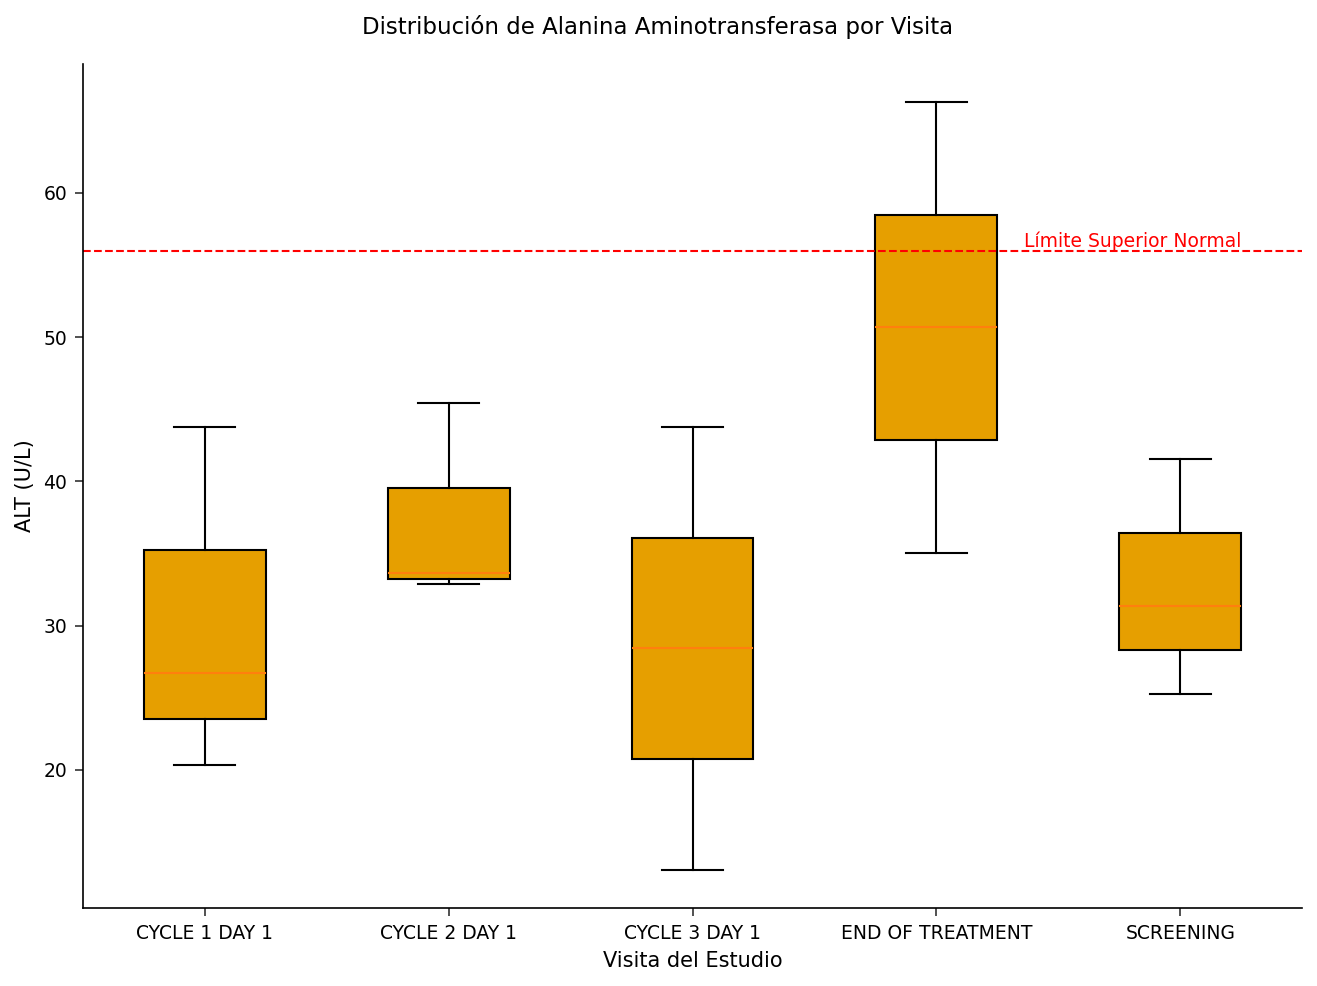

In [5]:
/* --------------------------------------------------------
   Diagrama de caja de los valores de ALT por visita
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.lab_import;
    DONDE lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / axis=y lineattrs=(pattern=dash color=red)
        ETIQUETA="Límite Superior Normal";
    XAXIS ETIQUETA="Visita del Estudio";
    YAXIS ETIQUETA="ALT (U/L)";
    TÍTULO "Distribución de Alanina Aminotransferasa por Visita";
EJECUTAR;

In [6]:
/* --------------------------------------------------------
   Análisis de rango de referencia vía PROC MEANS con ODS OUTPUT
   Estratificado por analito y visita para revisión del monitor médico
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.lab_import n mean std min max;
    CLASE lbtestcd visit;
    VAR lbstresn;
    ETIQUETA lbtestcd="Código de Analito" visit="Visita del Estudio"
             lbstresn="Resultado Numérico Estandarizado";
    SALIDA out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        min=min_value max=max_value;
EJECUTAR;

                                                  The MEANS Procedure

                             Analysis Variable : lbstresn Resultado Numérico Estandarizado

        Código de Analito   Visita del Estudio          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------------------
        ALB                 CYCLE 1 DAY 1                   3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB                 CYCLE 2 DAY 1                   2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB                 CYCLE 3 DAY 1                   2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB                 END OF TREATMENT                2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB                 SCREENING                       3      4.1666667      0.8533073      3.360000


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Código de Analito by Indicador de Anormalidad

Código de Analito  |      ALTO |      BAJO |    NORMAL |      Total
-------------------+-----------+-----------+-----------+-----------
ALB                |         0 |         1 |        11 |         12
-------------------+-----------+-----------+-----------+-----------
ALT                |         1 |         0 |        12 |         13
-------------------+-----------+-----------+-----------+-----------
AST                |         0 |         1 |        12 |         13
-------------------+-----------+-----------+-----------+-----------
BILI               |         0 |         0 |        13 |         13
-------------------+-----------+-----------+-----------+-----------
CREAT              |         0 |         0 |        13 |         13
-------------------+-----------+-----------+-----------+-----------
HGB                |         0 |         0 |        12 | 


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


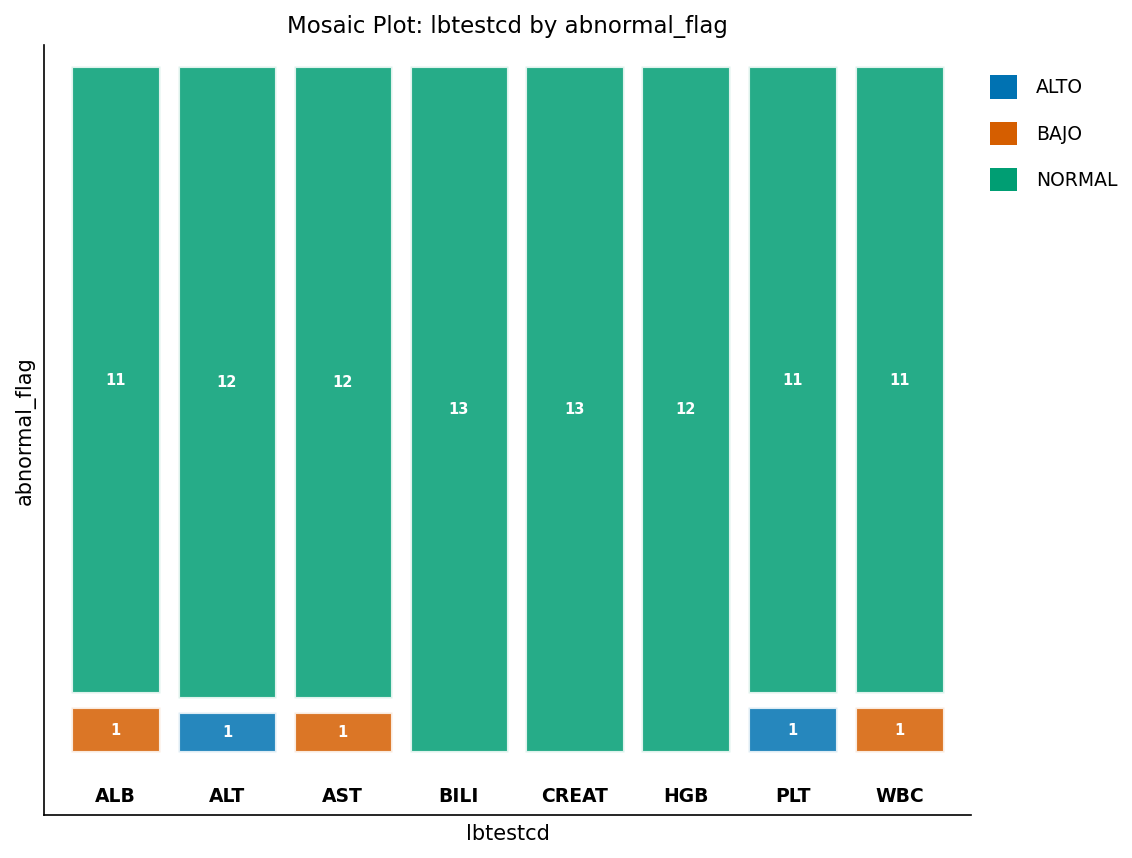

In [7]:
/* --------------------------------------------------------
   Marcar resultados fuera del rango de referencia
   -------------------------------------------------------- */
DATOS work.lab_flagged;
    ESTABLECER work.lab_import;
    LONGITUD abnormal_flag $8;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    SI lbstresn < low_ref ENTONCES abnormal_flag = 'BAJO';
    SINO SI lbstresn > high_ref ENTONCES abnormal_flag = 'ALTO';
    SINO abnormal_flag = 'NORMAL';
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    ETIQUETA lbtestcd="Código de Analito" abnormal_flag="Indicador de Anormalidad";
EJECUTAR;

---

### Interpretación

PROC IMPORT incorporó los 5,000 registros del laboratorio central desde el extracto CSV, y GUESSINGROWS=MAX permitió al lector escanear cada fila antes de fijar los tipos de columna, de modo que LBSTRESN se infirió como numérica en lugar de degradarse a carácter por un valor disperso temprano. PROC CONTENTS confirma 13 variables (5 numéricas, 8 de carácter), coincidiendo con la estructura de datos de laboratorio esperada. El análisis de rango de referencia arroja una ALT media global de 32.3 U/L (DE 11.8) y una AST media de 23.9 U/L (DE 7.9), ambas centradas dentro de los límites normales; el diagrama de caja muestra distribuciones de ALT comparables en las cinco visitas, con solo unos pocos valores que cruzan el límite superior normal de 56 U/L. En el conjunto de datos completo, 218 de 5,000 resultados (4.4%) quedan fuera de su rango de referencia. Debido a que los valores sintéticos se generan como variación simétrica alrededor del punto medio de referencia de cada analito, las señales fuera de rango se distribuyen de manera bastante uniforme entre analitos (ALB y PLT los más altos, con 5.1%, ALT el más bajo, con 3.7%) y entre visitas, sin una tendencia de tratamiento diseñada. Estas estadísticas resumen por analito y visita son el insumo que un monitor médico examinaría en busca de señales de laboratorio una vez que datos reales del estudio reemplacen el extracto generado.

---

In [8]:
/* --------------------------------------------------------
   Exportar el resumen de rango de laboratorio para el informe
   del monitor médico
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>